# StatArb Pairs: Optimized Mean-Reversion Trading System

## Project Overview

This Jupyter notebook implements a sophisticated **pairs trading strategy** using **statistical arbitrage** techniques and **Bayesian optimization**. The system is designed to identify and exploit mean-reversion opportunities in financial markets.

### Key Components:

1. **Data Collection & Preprocessing**
   - Download historical stock data using `yfinance`
   - Pair selection using cointegration tests

2. **Pairs Trading Strategy Development**
   - Implementation of `PairTradingStrategy` class
   - Utilization of key parameters: lookback, entry_threshold, stoploss_factor, half_life

3. **Backtesting Engine**
   - Custom `BacktestEngine` class using Backtrader
   - Comprehensive performance metrics and visualization

4. **Bayesian Optimization**
   - Parameter optimization using `skopt`
   - Objective function based on Sharpe Ratio

5. **Results Analysis**
   - Equity curve plotting
   - Trade table generation
   - Performance metrics calculation

### Project Structure:

1. **Data Download & Storage**
   - Function to download and save stock data for multiple tickers

2. **Pair Selection**
   - Cointegration tests, correlation analysis, and ADF test for pair selection

3. **Strategy Implementation**
   - `PairTradingStrategy` class with entry/exit logic and risk management

4. **Backtesting Engine**
   - `BacktestEngine` class for running and analyzing backtests

5. **Parameter Optimization**
   - Bayesian optimization to find optimal strategy parameters

6. **Main Execution**
   - Pair selection, parameter optimization, and final backtest execution

This project demonstrates the application of statistical methods and machine learning optimization in developing a robust pairs trading system.

# 1. Donwloand & Store the data

In [1]:
import refinitiv.data as rd
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import statsmodels.api as sm
from tqdm import tqdm
from statsmodels.tsa.stattools import coint, adfuller
from itertools import combinations
import backtrader as bt
from collections import deque
from tabulate import tabulate
from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.utils import use_named_args

rd.get_config()["http.request-timeout"] = 120
pd.set_option('future.no_silent_downcasting', True)

In [2]:
year_window = 10

endyear = dt.datetime.now().year
startyear = endyear - year_window + 1

start = dt.datetime(startyear,1,1).strftime('%Y-%m-%d')
end = dt.datetime.now().strftime('%Y-%m-%d')
vars = ['TR.PriceClose','TR.TotalReturn','TR.BIDPRICE',
        'TR.ASKPRICE','TR.Volume',
        'TR.CompanyMarketCapitalization']
query_list=[f'TR.PriceClose(Frq=D,SDate={start},EDate={end}).date']
for var in vars:
    query_list.append(f'{var}(Frq=D,SDate={start},EDate={end})')
query_list

['TR.PriceClose(Frq=D,SDate=2016-01-01,EDate=2025-11-30).date',
 'TR.PriceClose(Frq=D,SDate=2016-01-01,EDate=2025-11-30)',
 'TR.TotalReturn(Frq=D,SDate=2016-01-01,EDate=2025-11-30)',
 'TR.BIDPRICE(Frq=D,SDate=2016-01-01,EDate=2025-11-30)',
 'TR.ASKPRICE(Frq=D,SDate=2016-01-01,EDate=2025-11-30)',
 'TR.Volume(Frq=D,SDate=2016-01-01,EDate=2025-11-30)',
 'TR.CompanyMarketCapitalization(Frq=D,SDate=2016-01-01,EDate=2025-11-30)']

In [3]:
try:
    stocklist = pd.read_pickle('spx_constituents.pkl')
except:
    rd.open_session()
    stocklist = rd.get_data(
            universe = ['.SPX'],
            fields = [f'TR.IndexConstituentRIC(SDate={year}-01-01)' for year in range(startyear, endyear + 1)],
    )
    rd.close_session()
    stocklist = stocklist.iloc[:, 1:]
    stocklist.columns = range(startyear, endyear + 1)
display(stocklist)

,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,CHRW.OQ,CHRW.OQ,CHRW.OQ,CHRW.OQ,CHRW.OQ,POOL.OQ,POOL.OQ,POOL.OQ,POOL.OQ,POOL.OQ
1,CNP.N,AJG.N,AJG.N,AJG.N,AJG.N,CHRW.OQ,CHRW.OQ,CHRW.OQ,CHRW.OQ,CHRW.OQ
2,WM.N,CNP.N,CNP.N,CNP.N,CNP.N,AJG.N,AJG.N,AJG.N,AJG.N,AJG.N
3,PRGO.N,WM.N,WM.N,WM.N,AMCR.N,CNP.N,CNP.N,CNP.N,CNP.N,CNP.N
4,BA.N,PRGO.N,PRGO.N,PRGO.N,WM.N,AMCR.N,AMCR.N,AMCR.N,AMCR.N,AMCR.N
...,...,...,...,...,...,...,...,...,...,...
501,SCHW.N,FLIR.OQ^E21,SCHW.N,DXC.N,DXC.N,SNPS.OQ,SNPS.OQ,SIVB.OQ^C23,J.N,J.N
502,LVLT.N^K17,SCHW.N,DXC.N,SNPS.OQ,SNPS.OQ,J.N,J.N,AVY.N,AVY.N,AVY.N
503,J.N,LVLT.N^K17,SNPS.OQ,J.N,J.N,SIVB.OQ^C23,SIVB.OQ^C23,,,
504,AVY.N,J.N,J.N,SIVB.OQ^C23,SIVB.OQ^C23,AVY.N,AVY.N,,,


In [4]:
stocklist.to_pickle('spx_constituents.pkl')

In [5]:
# rd.open_session()
# stocklist = pd.DataFrame()
# for year in tqdm(range(startyear, endyear + 1)):
#     df = rd.get_data(
#             universe = ['.SPX'],
#             fields = [f'TR.IndexConstituentRIC(SDate={year}-01-01)'],
#     )
#     stocklist = pd.concat([stocklist, df['Constituent RIC'].rename(year)], axis=1)
# rd.close_session()
# display(stocklist)

In [6]:
unique_stock = sorted(stocklist.stack().unique())
unique_stock.remove('')
unique_stock

['A.N',
 'AABA.OQ^J19',
 'AAL.OQ',
 'AAP.N',
 'AAPL.OQ',
 'ABBV.N',
 'ABMD.OQ^L22',
 'ABNB.OQ',
 'ABT.N',
 'ACGL.OQ',
 'ACN.N',
 'ADBE.OQ',
 'ADI.OQ',
 'ADM.N',
 'ADP.OQ',
 'ADSK.OQ',
 'ADT.N^E16',
 'AEE.N',
 'AEP.OQ',
 'AES.N',
 'AET.N^K18',
 'AFL.N',
 'AGN.N^E20',
 'AIG.N',
 'AIV.N',
 'AIZ.N',
 'AJG.N',
 'AKAM.OQ',
 'ALB.N',
 'ALGN.OQ',
 'ALK.N',
 'ALL.N',
 'ALLE.N',
 'ALXN.OQ^G21',
 'AMAT.OQ',
 'AMCR.N',
 'AMD.OQ',
 'AME.N',
 'AMG.N',
 'AMGN.OQ',
 'AMP.N',
 'AMT.N',
 'AMZN.OQ',
 'AN.N',
 'ANDV.N^J18',
 'ANET.N',
 'ANSS.OQ^G25',
 'AON.N',
 'AOS.N',
 'APA.OQ',
 'APC.N^H19',
 'APD.N',
 'APH.N',
 'APO.N',
 'APTV.N',
 'ARE.N',
 'ARG.N^E16',
 'ATO.N',
 'ATVI.OQ^J23',
 'AVB.N',
 'AVGO.OQ',
 'AVY.N',
 'AWK.N',
 'AXON.OQ',
 'AXP.N',
 'AYI.N',
 'AZO.N',
 'BA.N',
 'BAC.N',
 'BALL.N',
 'BAX.N',
 'BBBY.OQ^E23',
 'BBWI.N',
 'BBY.N',
 'BCR.N^L17',
 'BDX.N',
 'BEN.N',
 'BFH.N',
 'BFb.N',
 'BG.N',
 'BHF.OQ',
 'BIIB.OQ',
 'BIO.N',
 'BK.N',
 'BKNG.OQ',
 'BKR.N',
 'BKR.OQ',
 'BLDR.N',
 'BLK.N',
 'BMY.N

In [ ]:
try:
    # data = pd.read_pickle('long_data.pkl')
    data1 = pd.read_pickle('long_data1.pkl')
    data2 = pd.read_pickle('long_data2.pkl')
    data = pd.concat([data1, data2])
except:
    rd.open_session()
    batch_size = 50
    data = []
    for i in tqdm(range(0, len(unique_stock), batch_size)):
        df = rd.get_data(
            universe = unique_stock[i:i+batch_size],
            fields = query_list,
            )
        data.append(df)
    rd.close_session()
    data = pd.concat(data, ignore_index=True)
    data.to_pickle('long_data.pkl')
display(data)      

,Instrument,Date,Price Close,Total Return,Bid Price,Ask Price,Volume,Company Market Capitalization
0,A.N,2016-01-04,40.69,-0.563581,40.68,40.69,1167911,13516033514.1
1,A.N,2016-01-05,40.55,-0.563581,40.55,40.56,664634,13469529589.5
2,A.N,2016-01-06,40.73,-1.800254,40.72,40.73,687280,13529320349.700001
3,A.N,2016-01-07,39.0,2.34375,39.0,39.01,922848,12954664710.0
4,A.N,2016-01-08,38.59,1.553719,38.58,38.59,1445601,12818474645.1
...,...,...,...,...,...,...,...,...
1510970,ZTS.N,2025-11-21,122.06,-2.833479,122.05,122.11,1275064,53791013700.839996
1510971,ZTS.N,2025-11-24,122.87,-1.460481,122.85,122.86,2222244,54147975204.18
1510972,ZTS.N,2025-11-25,127.89,-3.0404,127.83,127.84,1104654,56360255138.459999
1510973,ZTS.N,2025-11-26,127.69,0.020829,127.65,127.66,840080,56272116495.660004


In [8]:
data['Instrument'].unique()

<StringArray>
[        'A.N', 'AABA.OQ^J19',      'AAL.OQ',       'AAP.N',     'AAPL.OQ',
      'ABBV.N', 'ABMD.OQ^L22',     'ABNB.OQ',       'ABT.N',     'ACGL.OQ',
 ...
 'XLNX.OQ^B22',       'XOM.N',     'XRAY.OQ',      'XRX.OQ',       'XYL.N',
       'YUM.N',       'ZBH.N',     'ZBRA.OQ',     'ZION.OQ',       'ZTS.N']
Length: 682, dtype: string

In [9]:
failed_stocks = list(set(unique_stock) - set(data['Instrument'].unique()))
# pd.Series(failed_stocks).to_csv('failed_stocks.csv', index=False)
failed_stocks

[]

In [ ]:
# data = pd.read_pickle('long_data.pkl') 
# failed_stocks = pd.read_pickle('failed_stocks.pkl')
# data = pd.concat([data, failed_stocks], ignore_index=True)
data.drop_duplicates(subset=["Date", "Instrument"], inplace=True)
data.reset_index(drop=True, inplace=True)
data

,Instrument,Date,Price Close,Total Return,Bid Price,Ask Price,Volume,Company Market Capitalization
0,A.N,2016-01-04,40.69,-0.563581,40.68,40.69,1167911,13516033514.1
1,A.N,2016-01-05,40.55,-0.563581,40.55,40.56,664634,13469529589.5
2,A.N,2016-01-06,40.73,-1.800254,40.72,40.73,687280,13529320349.700001
3,A.N,2016-01-07,39.0,2.34375,39.0,39.01,922848,12954664710.0
4,A.N,2016-01-08,38.59,1.553719,38.58,38.59,1445601,12818474645.1
...,...,...,...,...,...,...,...,...
1510970,ZTS.N,2025-11-21,122.06,-2.833479,122.05,122.11,1275064,53791013700.839996
1510971,ZTS.N,2025-11-24,122.87,-1.460481,122.85,122.86,2222244,54147975204.18
1510972,ZTS.N,2025-11-25,127.89,-3.0404,127.83,127.84,1104654,56360255138.459999
1510973,ZTS.N,2025-11-26,127.69,0.020829,127.65,127.66,840080,56272116495.660004


In [11]:
close_df = data.pivot(index="Date", columns="Instrument", values="Price Close")
ret_df   = data.pivot(index="Date", columns="Instrument", values="Total Return")
bid_df   = data.pivot(index="Date", columns="Instrument", values="Bid Price")
ask_df   = data.pivot(index="Date", columns="Instrument", values="Ask Price")
vol_df   = data.pivot(index="Date", columns="Instrument", values="Volume")
cap_df   = data.pivot(index="Date", columns="Instrument", values="Company Market Capitalization")

close_df

Instrument,A.N,AABA.OQ^J19,AAL.OQ,AAP.N,AAPL.OQ,ABBV.N,ABMD.OQ^L22,ABNB.OQ,ABT.N,ACGL.OQ,...,XLNX.OQ^B22,XOM.N,XRAY.OQ,XRX.OQ,XYL.N,YUM.N,ZBH.N,ZBRA.OQ,ZION.OQ,ZTS.N
Date,,,,,,,,,,,,,,,,,,,,,
NaT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2016-01-04,40.69,31.4,40.91,152.24,26.3375,57.61,85.24,<NA>,42.93,21.82311,...,45.8,77.46,58.86,27.136298,36.08,51.922889,98.768223,66.49,26.71,47.27
2016-01-05,40.55,32.2,40.52,151.2,25.6775,57.37,85.0,<NA>,42.92,21.902352,...,46.48,78.12,60.06,27.083606,36.07,51.79346,100.824883,64.82,26.42,48.01
2016-01-06,40.73,32.16,41.23,147.2,25.175,57.38,85.3,<NA>,42.56,21.937218,...,45.63,77.47,59.19,26.741109,35.62,51.426742,101.261439,62.23,25.65,48.02
2016-01-07,39.0,30.16,40.45,148.83,24.1125,57.21,81.92,<NA>,41.54,21.91503,...,43.83,76.23,58.67,26.003423,34.7,49.67225,98.933144,59.41,24.88,46.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-21,151.25,<NA>,12.87,51.7,271.49,236.28,<NA>,114.26,128.11,92.46,...,<NA>,117.08,10.58,2.62,140.39,152.98,92.18,240.95,52.12,122.06
2025-11-24,153.6,<NA>,13.1,50.93,275.92,229.51,<NA>,114.41,127.19,91.94,...,<NA>,115.97,10.73,2.72,141.83,151.08,93.52,242.45,51.89,122.87
2025-11-25,157.2,<NA>,13.46,51.06,276.97,231.8,<NA>,118.56,128.05,93.61,...,<NA>,114.51,11.09,2.73,141.51,154.0,97.07,249.31,53.23,127.89


In [12]:
close_df.drop('NaT', inplace=True)
ret_df.drop('NaT', inplace=True)
bid_df.drop('NaT', inplace=True)
ask_df.drop('NaT', inplace=True)
vol_df.drop('NaT', inplace=True)
cap_df.drop('NaT', inplace=True)

In [13]:
close_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2492 entries, 2016-01-04 to 2025-11-28
Columns: 682 entries, A.N to ZTS.N
dtypes: Float64(682)
memory usage: 14.6 MB


In [14]:
close_df.isna().mean().mean(), ret_df.isna().mean().mean(), bid_df.isna().mean().mean(), ask_df.isna().mean().mean(), vol_df.isna().mean().mean(), cap_df.isna().mean().mean()

(0.1109821222633836,
 0.1109762383321644,
 0.1109762383321644,
 0.1109762383321644,
 0.1109762383321644,
 0.12170382173100548)

In [15]:
available_stocks = close_df.loc['2016-01-01':'2020-12-31'].isna().sum(axis=0)
available_stocks = available_stocks[available_stocks == 0].index.tolist()
len(available_stocks)

575

In [16]:
# import yfinance as yf
# import os
# from datetime import datetime

# # # List of 50 stock tickers
# list_tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'BRK-A', 'V', 'JPM', 'JNJ', 'WMT', 'UNH', 'MA', 'PG', 'NVDA', 'HD', 'DIS', 'PYPL', 'BAC', 'CMCSA', 'ADBE', 'XOM', 'INTC', 'VZ', 'NFLX', 'T', 'CRM', 'ABT', 'CSCO', 'PEP', 'PFE', 'KO', 'MRK', 'NKE', 'CVX', 'WFC', 'ORCL', 'MCD', 'COST', 'ABBV', 'MDT', 'TMO', 'ACN', 'HON', 'UNP', 'IBM', 'UPS', 'LIN', 'LLY', 'AMT']

# # # list of 10 stock tickers
# # list_tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'BRK-A', 'V', 'JPM', 'JNJ']

# # Set start and end times
# start_time = '2020-01-01'
# end_time = '2025-01-01'

# # Create a folder to save data if it doesn't exist
# folder_name = 'stock_data'
# if not os.path.exists(folder_name):
#     os.makedirs(folder_name)

# # Function to download and save data for a stock
# def download_and_save_stock_data(ticker):
#     try:
#         # Download data
#         data = yf.download(ticker, start=start_time, end=end_time, multi_level_index=False)
        
#         # Create file name
#         file_name = os.path.join(folder_name, f"{ticker}.csv")
        
#         # Save data to CSV file
#         data.to_csv(file_name)
#         print(f"Downloaded and saved data for {ticker}")
#     except Exception as e:
#         print(f"Error downloading data for {ticker}: {str(e)}")

# # Download and save data for all stocks
# for ticker in list_tickers:
#     download_and_save_stock_data(ticker)

# print("Completed downloading data for all stocks.")

# 2. Find best 2 Pairs for Pair Trading Strategy ( Cointegration Test, Correlation, ADF Test )

In [17]:
# import numpy as np
# import pandas as pd
# from statsmodels.tsa.stattools import coint, adfuller
# import os
# from itertools import combinations

# def load_stock_data(ticker, data_folder='stock_data'):
#     """Load stock data from CSV file."""
#     return pd.read_csv(os.path.join(data_folder, f'{ticker}.csv'), index_col='Date', parse_dates=True)

# def calculate_log_spread_and_zscore(stock1, stock2):
#     """Calculate log spread and its z-score."""
#     log_spread = np.log(stock1['Close']) - np.log(stock2['Close'])
#     z_score = (log_spread - log_spread.mean()) / log_spread.std()
#     return log_spread, z_score

# def analyze_pair(stock1, stock2):
#     """Analyze a pair of stocks for cointegration, correlation, and stationarity."""
#     log_spread, z_score = calculate_log_spread_and_zscore(stock1, stock2)
    
#     # Check Cointegration
#     score, pvalue, _ = coint(stock1['Close'], stock2['Close'])
    
#     # Calculate Correlation
#     correlation = stock1['Close'].corr(stock2['Close'])
    
#     # Augmented Dickey-Fuller Test on log spread
#     adf_result = adfuller(log_spread)
    
#     return {
#         'cointegration_pvalue': pvalue,
#         'correlation': correlation,
#         'adf_pvalue': adf_result[1],
#         'log_spread': log_spread,
#         'z_score': z_score
#     }

# def analyze_all_pairs(tickers, data_folder='stock_data'):
#     """Analyze all possible pairs from the given list of tickers."""
#     results = []
    
#     for ticker1, ticker2 in combinations(tickers, 2):
#         try:
#             stock1 = load_stock_data(ticker1, data_folder)
#             stock2 = load_stock_data(ticker2, data_folder)
            
#             # Ensure both stocks have the same date range
#             common_dates = stock1.index.intersection(stock2.index)
#             stock1 = stock1.loc[common_dates]
#             stock2 = stock2.loc[common_dates]
            
#             result = analyze_pair(stock1, stock2)
            
#             results.append({
#                 'pair': f'{ticker1}-{ticker2}',
#                 'cointegration_pvalue': result['cointegration_pvalue'],
#                 'correlation': result['correlation'],
#                 'adf_pvalue': result['adf_pvalue'],
#                 'mean_zscore': result['z_score'].mean(),
#                 'std_zscore': result['z_score'].std()
#             })
#         except Exception as e:
#             print(f"Error analyzing pair {ticker1}-{ticker2}: {str(e)}")
    
#     return pd.DataFrame(results)

# def filter_suitable_pairs(df_results, cointegration_threshold=0.05, adf_threshold=0.05):
#     """Filter pairs suitable for pair trading based on cointegration and stationarity."""
#     return df_results[
#         (df_results['cointegration_pvalue'] < cointegration_threshold) &
#         (df_results['adf_pvalue'] < adf_threshold)
#     ].sort_values('correlation', ascending=False)

# def find_best_pair(tickers, data_folder='stock_data', cointegration_threshold=0.05, adf_threshold=0.05):
#     """Find the best pair for pair trading from the given list of tickers."""
#     all_pairs = analyze_all_pairs(tickers, data_folder)
#     suitable_pairs = filter_suitable_pairs(all_pairs, cointegration_threshold, adf_threshold)
    
#     if suitable_pairs.empty:
#         return None, pd.DataFrame()  # Return None and an empty DataFrame instead of a string
    
#     best_pair = suitable_pairs.iloc[0]
#     stock1, stock2 = best_pair['pair'].split('-')
    
#     # Load data for the best pair to calculate additional metrics
#     stock1_data = load_stock_data(stock1, data_folder)
#     stock2_data = load_stock_data(stock2, data_folder)
#     common_dates = stock1_data.index.intersection(stock2_data.index)
#     stock1_data = stock1_data.loc[common_dates]
#     stock2_data = stock2_data.loc[common_dates]
    
#     log_spread, z_score = calculate_log_spread_and_zscore(stock1_data, stock2_data)
    
#     return {
#         'stock1': stock1,
#         'stock2': stock2,
#         'correlation': best_pair['correlation'],
#         'cointegration_pvalue': best_pair['cointegration_pvalue'],
#         'adf_pvalue': best_pair['adf_pvalue'],
#         'mean_zscore': best_pair['mean_zscore'],
#         'std_zscore': best_pair['std_zscore'],
#         'log_spread': log_spread,
#         'z_score': z_score
#     }, suitable_pairs

In [18]:
def calculate_log_spread_and_zscore(close1: pd.Series, close2: pd.Series):
    """
    Calculate log spread and its z-score from two price series.
    close1, close2: price series aligned on the same dates (no NaNs).
    """
    log_spread = np.log(close1) - np.log(close2)
    z_score = (log_spread - log_spread.mean()) / log_spread.std()
    return log_spread, z_score

def analyze_pair(close1: pd.Series, close2: pd.Series):
    """
    Analyze a pair of stocks for cointegration, correlation, and stationarity.
    close1, close2: price series aligned on same dates (no NaNs).
    """
    log_spread, z_score = calculate_log_spread_and_zscore(close1, close2)
    
    # Cointegration test
    score, pvalue, _ = coint(close1, close2)
    
    # Correlation
    correlation = close1.corr(close2)
    
    # ADF test on log spread
    adf_result = adfuller(log_spread)
    
    return {
        'cointegration_pvalue': pvalue,
        'correlation': correlation,
        'adf_pvalue': adf_result[1],
        'log_spread': log_spread,
        'z_score': z_score
    }

def analyze_all_pairs(tickers, close_df: pd.DataFrame):
    """
    Analyze all possible pairs from the given list of tickers
    using a single close price DataFrame (close_df).
    """
    results = []
    
    for ticker1, ticker2 in tqdm(combinations(tickers, 2), total=len(list(combinations(tickers, 2)))):
        try:
            # Take two columns and drop rows with NaNs in either
            pair_prices = close_df[[ticker1, ticker2]].dropna()
            
            # If not enough data, skip (optional)
            if len(pair_prices) < 50:  # you can adjust this threshold
                continue
            
            close1 = pair_prices[ticker1]
            close2 = pair_prices[ticker2]
            
            result = analyze_pair(close1, close2)
            
            results.append({
                'pair': f'{ticker1}-{ticker2}',
                'cointegration_pvalue': result['cointegration_pvalue'],
                'correlation': result['correlation'],
                'adf_pvalue': result['adf_pvalue'],
                'mean_zscore': result['z_score'].mean(),
                'std_zscore': result['z_score'].std()
            })
        except Exception as e:
            print(f"Error analyzing pair {ticker1}-{ticker2}: {str(e)}")
    
    return pd.DataFrame(results)

def filter_suitable_pairs(df_results, cointegration_threshold=0.05, adf_threshold=0.05):
    """
    Filter pairs suitable for pair trading based on cointegration and stationarity.
    """
    return df_results[
        (df_results['cointegration_pvalue'] < cointegration_threshold) &
        (df_results['adf_pvalue'] < adf_threshold)
    ].sort_values('correlation', ascending=False)

def find_best_pair(tickers, close_df: pd.DataFrame,
                   cointegration_threshold=0.05, adf_threshold=0.05):
    """
    Find the best pair for pair trading from the given list of tickers
    using close_df (all prices in one DataFrame).
    """
    all_pairs = analyze_all_pairs(tickers, close_df)
    suitable_pairs = filter_suitable_pairs(all_pairs, cointegration_threshold, adf_threshold)
    
    if suitable_pairs.empty:
        return None, pd.DataFrame()
    
    best_pair = suitable_pairs.iloc[0]
    stock1, stock2 = best_pair['pair'].split('-')
    
    # Rebuild aligned price series for the best pair
    pair_prices = close_df[[stock1, stock2]].dropna()
    close1 = pair_prices[stock1]
    close2 = pair_prices[stock2]
    
    log_spread, z_score = calculate_log_spread_and_zscore(close1, close2)
    
    return {
        'stock1': stock1,
        'stock2': stock2,
        'correlation': best_pair['correlation'],
        'cointegration_pvalue': best_pair['cointegration_pvalue'],
        'adf_pvalue': best_pair['adf_pvalue'],
        'mean_zscore': best_pair['mean_zscore'],
        'std_zscore': best_pair['std_zscore'],
        'log_spread': log_spread,
        'z_score': z_score
    }, suitable_pairs

# 3. Pair Trading Strategy

## 3.1. Calculate Kappa & Half-Life

In [19]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import statsmodels.api as sm

# def calculate_spread(stock1, stock2):
#     return np.log(stock1['Close']) - np.log(stock2['Close'])

# def calculate_half_life(spread):
#     spread_lag = spread.shift(1)
#     spread_lag.iloc[0] = spread_lag.iloc[1]
    
#     spread_ret = spread - spread_lag
#     spread_ret.iloc[0] = spread_ret.iloc[1]
    
#     spread_lag2 = sm.add_constant(spread_lag)
    
#     model = sm.OLS(spread_ret, spread_lag2)
#     res = model.fit()
    
#     halflife = -np.log(2) / res.params[1]
    
#     return halflife

# def calculate_kappa_half_life(spread):
#     # Calculate Kappa
#     spread_lag = spread.shift(1)
#     delta_spread = spread - spread_lag
#     reg = np.polyfit(spread_lag.dropna(), delta_spread.dropna(), deg=1)
#     kappa = -reg[0]
    
#     # Calculate Half-Life
#     half_life = calculate_half_life(spread)
    
#     return kappa, half_life

# def calculate_kappa_and_half_life(stock1_data, stock2_data, plot=True):
#     # Ensure both stocks have the same date range
#     common_dates = stock1_data.index.intersection(stock2_data.index)
#     stock1_data = stock1_data.loc[common_dates]
#     stock2_data = stock2_data.loc[common_dates]
    
#     # Calculate spread
#     spread = calculate_spread(stock1_data, stock2_data)
    
#     # Calculate Kappa and Half-Life
#     kappa, half_life = calculate_kappa_half_life(spread)
    
#     if plot:
#         # Plot the spread
#         plt.figure(figsize=(12, 6))
#         plt.plot(spread)
#         plt.title(f'Price Spread')
#         plt.xlabel('Date')
#         plt.ylabel('Spread')
#         plt.show()
    
#     return kappa, half_life

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

def calculate_spread_from_series(close1: pd.Series, close2: pd.Series) -> pd.Series:
    """
    Calculate log spread from two aligned close-price series.
    Both series should share the same Date index and have no NaNs.
    """
    return np.log(close1) - np.log(close2)


def calculate_half_life(spread: pd.Series) -> float:
    """
    Estimate half-life of mean reversion of a spread using
    an AR(1) regression: Δspread_t = α + β * spread_{t-1} + ε_t.
    Half-life = -ln(2) / β.
    """
    # Lagged spread
    spread_lag = spread.shift(1)
    spread_ret = spread - spread_lag  # Δspread

    # Drop initial NaNs
    data = pd.concat([spread_ret, spread_lag], axis=1).dropna()
    data.columns = ['spread_ret', 'spread_lag']

    # Regress Δspread on lagged spread
    X = sm.add_constant(data['spread_lag'].to_numpy())
    y = data['spread_ret']
    model = sm.OLS(y, X)
    res = model.fit()

    beta = res.params['x1']
    halflife = -np.log(2) / beta

    return halflife


def calculate_kappa_half_life(spread: pd.Series):
    """
    Compute kappa (speed of mean reversion) and half-life.
    Kappa is estimated by regressing Δspread on spread_{t-1}:
        Δspread_t = a - kappa * spread_{t-1} + ε_t
    so kappa = -slope.
    """
    spread_lag = spread.shift(1)
    delta_spread = spread - spread_lag

    df = pd.concat([spread_lag, delta_spread], axis=1).dropna()
    df.columns = ['spread_lag', 'delta_spread']

    # np.polyfit(y = delta_spread, x = spread_lag)
    reg = np.polyfit(df['spread_lag'], df['delta_spread'], deg=1)
    kappa = -reg[0]

    half_life = calculate_half_life(spread)

    return kappa, half_life


def calculate_kappa_and_half_life_from_close_df(
    ticker1: str,
    ticker2: str,
    close_df: pd.DataFrame,
    plot: bool = True
):
    """
    Wrapper that:
    - extracts close prices for ticker1 and ticker2 from close_df,
    - aligns them on common dates and drops NaNs,
    - computes spread, kappa, and half-life,
    - optionally plots the spread.
    """
    # Extract and align the two price series
    pair_prices = close_df[[ticker1, ticker2]].dropna()
    close1 = pair_prices[ticker1]
    close2 = pair_prices[ticker2]

    # Calculate spread
    spread = calculate_spread_from_series(close1, close2)

    # Calculate Kappa and Half-Life
    kappa, half_life = calculate_kappa_half_life(spread)

    if plot:
        plt.figure(figsize=(12, 6))
        plt.plot(spread)
        plt.title(f'Log Price Spread: {ticker1} - {ticker2}')
        plt.xlabel('Date')
        plt.ylabel('Spread')
        plt.tight_layout()
        plt.show()

    return kappa, half_life

## 3.2 - Pair Trading Strategy ( Z-Score, Entry, Exit, Profit )

### use with Kappa & Half-Life

In [21]:
# import backtrader as bt
# import numpy as np
# from collections import deque

# class PairTradingStrategy(bt.Strategy):
#     params = (
#         ('lookback', 20),
#         ('entry_threshold', 1.5),  # Entry threshold in terms of standard deviations
#         ('stoploss_factor', 2.0),  # Stop-loss threshold in terms of standard deviations
#         ('holding_time_factor', 1.5),  # Factor to determine max holding time based on half-life
#         ('half_life', 14),  # Estimated half-life of mean reversion in days
#         ('stock1', None),
#         ('stock2', None),
#     )

#     def __init__(self):
#         # Get the data for the two stocks
#         self.stock1 = self.getdatabyname(self.params.stock1)
#         self.stock2 = self.getdatabyname(self.params.stock2)

#         # Initialize spread and mean/std
#         self.spread = []
#         self.mean = None
#         self.std = None
#         self.entry_price = None # Entry price for the current position
#         self.entry_date = None # Entry date for the current position

#         # Calculate max holding time
#         self.max_holding_time = int(self.params.holding_time_factor * self.params.half_life)

#         # Custom metrics tracking
#         self.trades = []
#         self.equity_curve = [self.broker.getvalue()]
#         self.returns = deque(maxlen=252)  # For annual Sharpe ratio
#         self.max_drawdown = 0
#         self.peak = self.broker.getvalue()

#     def next(self):
#         # Calculate the spread
#         spread = np.log(self.stock1.close[0]) - np.log(self.stock2.close[0])
#         self.spread.append(spread)

#         # Wait until we have enough data
#         if len(self.spread) <= self.params.lookback:
#             return

#         # Calculate mean and standard deviation
#         self.mean = np.mean(self.spread[-self.params.lookback:])
#         self.std = np.std(self.spread[-self.params.lookback:])

#         # Calculate trading thresholds
#         buy_threshold = self.mean - self.params.entry_threshold * self.std
#         sell_threshold = self.mean + self.params.entry_threshold * self.std

#         # Trading logic
#         # No existing position
#         if not self.position: 
#             if spread < buy_threshold:
#                 self.buy(data=self.stock1)
#                 self.sell(data=self.stock2)
#                 self.entry_price = spread
#                 self.entry_date = len(self)
#                 self.log_trade('ENTRY LONG')
#             elif spread > sell_threshold:
#                 self.sell(data=self.stock1)
#                 self.buy(data=self.stock2)
#                 self.entry_price = spread
#                 self.entry_date = len(self)
#                 self.log_trade('ENTRY SHORT')
#         # Existing position
#         else: 
#             # Check for exit conditions
#             days_since_entry = len(self) - self.entry_date

#             # Trong phần exit logic
#             if (self.position.size > 0 and spread >= self.mean) or \
#             (self.position.size < 0 and spread <= self.mean):
#                 self.close(data=self.stock1)
#                 self.close(data=self.stock2)
#                 self.log_trade('EXIT', days_since_entry, reason="Spread Reversion")
#             elif days_since_entry >= self.max_holding_time:
#                 self.close(data=self.stock1)
#                 self.close(data=self.stock2)
#                 self.log_trade('EXIT', days_since_entry, reason="Max Holding Time")
#                 return

#             # Check for stop-loss
#             stop_loss_threshold = self.params.stoploss_factor * self.std
#             if abs(spread - self.entry_price) > stop_loss_threshold:
#                 self.close(data=self.stock1)
#                 self.close(data=self.stock2)
#                 self.log_trade('STOP-LOSS', days_since_entry, reason="Stop-Loss Hit")

#         # Update metrics
#         current_value = self.broker.getvalue()
#         self.equity_curve.append(current_value)
        
#         # Calculate return
#         if len(self.equity_curve) > 1:
#             daily_return = (current_value - self.equity_curve[-2]) / self.equity_curve[-2]
#             self.returns.append(daily_return)
        
#         # Update max drawdown
#         if current_value > self.peak:
#             self.peak = current_value
#         dd = (self.peak - current_value) / self.peak
#         if dd > self.max_drawdown:
#             self.max_drawdown = dd

#     def log_trade(self, action, days_held=None, reason=None):
#         if action.startswith('ENTRY'):
#             self.entry_date = len(self)
#             self.entry_price1 = self.stock1.close[0]
#             self.entry_price2 = self.stock2.close[0]
#         elif action in ['EXIT', 'STOP-LOSS']:
#             exit_price1 = self.stock1.close[0]
#             exit_price2 = self.stock2.close[0]
#             pnl = self.broker.getvalue() - self.equity_curve[-1]
#             pnl_pct = (pnl / self.equity_curve[-1]) * 100
#             self.trades.append({
#                 'entry_date': self.data.datetime.date(-days_held) if days_held is not None else None,
#                 'exit_date': self.data.datetime.date(0),
#                 'days_held': days_held,
#                 'pnl': pnl,
#                 'pnl_pct': pnl_pct,
#                 'entry_price1': self.entry_price1,
#                 'entry_price2': self.entry_price2,
#                 'exit_price1': exit_price1,
#                 'exit_price2': exit_price2,
#                 'exit_type': action,
#                 'exit_reason': reason
#             })

#     def stop(self):
#         # Calculate final metrics
#         self.total_trades = len(self.trades)
#         self.winning_trades = sum(1 for trade in self.trades if trade['pnl'] > 0)
#         self.losing_trades = sum(1 for trade in self.trades if trade['pnl'] <= 0)
#         self.win_rate = self.winning_trades / self.total_trades if self.total_trades > 0 else 0

#         self.total_return = (self.equity_curve[-1] - self.equity_curve[0]) / self.equity_curve[0]
#         self.mean_return = np.mean(self.returns) if self.returns else 0
#         self.std_return = np.std(self.returns) if self.returns else 0
#         self.sharpe_ratio = np.sqrt(252) * self.mean_return / self.std_return if self.std_return != 0 else 0

#         # Store all metrics in a dictionary for easy access
#         self.metrics = {
#             'Initial Capital': self.equity_curve[0],
#             'Final Portfolio Value': self.equity_curve[-1],
#             'Total Return (%)': self.total_return * 100,
#             'Sharpe Ratio': self.sharpe_ratio,
#             'Max Drawdown (%)': self.max_drawdown * 100,
#             'Total Trades': self.total_trades,
#             'Winning Trades': self.winning_trades,
#             'Losing Trades': self.losing_trades,
#             'Win Rate (%)': self.win_rate * 100,
#             'Mean Daily Return (%)': self.mean_return * 100,
#             'Std Dev of Daily Return (%)': self.std_return * 100
#         }

In [22]:
class PairTradingStrategy(bt.Strategy):
    params = (
        ('lookback', 20),
        ('entry_threshold', 1.5),      # Entry threshold (in std dev)
        ('stoploss_factor', 2.0),      # Stop-loss threshold (in std dev)
        ('holding_time_factor', 1.5),  # Max holding time = factor * half-life
        ('half_life', 14),             # Estimated half-life (days)
        ('stock1', None),
        ('stock2', None),
        ('size', 1),                   # Position size per leg
    )

    def __init__(self):
        # Two data feeds identified by name when adding to cerebro
        self.stock1 = self.getdatabyname(self.params.stock1)
        self.stock2 = self.getdatabyname(self.params.stock2)

        # Rolling spread window
        self.spread_window = deque(maxlen=self.params.lookback)
        self.mean = None
        self.std = None

        # Entry info
        self.entry_spread = None
        self.entry_bar = None
        self.entry_value = None
        self.entry_price1 = None
        self.entry_price2 = None
        self.entry_side = None  # 'LONG' (long spread) or 'SHORT'

        # Max holding time based on half-life
        self.max_holding_time = int(self.params.holding_time_factor * self.params.half_life)

        # Metrics
        self.trades = []
        self.equity_curve = [self.broker.getvalue()]
        self.returns = deque(maxlen=252)  # daily returns for annual Sharpe
        self.max_drawdown = 0.0
        self.peak = self.broker.getvalue()

    def next(self):
        # --- Compute spread (log price difference) ---
        spread = np.log(self.stock1.close[0]) - np.log(self.stock2.close[0])
        self.spread_window.append(spread)

        # Need enough history for lookback stats
        if len(self.spread_window) < self.params.lookback:
            self._update_metrics()
            return

        # --- Rolling mean/std of spread ---
        spreads = np.array(self.spread_window)
        self.mean = spreads.mean()
        self.std = spreads.std(ddof=1)  # sample std

        if self.std == 0:
            self._update_metrics()
            return

        buy_threshold = self.mean - self.params.entry_threshold * self.std   # long spread
        sell_threshold = self.mean + self.params.entry_threshold * self.std  # short spread

        # Current positions on each leg
        pos1 = self.getposition(self.stock1).size
        pos2 = self.getposition(self.stock2).size
        have_position = (pos1 != 0) or (pos2 != 0)

        # --- Trading logic ---
        if not have_position:
            # ENTRY: long spread (long stock1, short stock2)
            if spread < buy_threshold:
                self.buy(data=self.stock1, size=self.params.size)
                self.sell(data=self.stock2, size=self.params.size)
                self.entry_spread = spread
                self.entry_bar = len(self)
                self.entry_value = self.broker.getvalue()
                self.entry_side = 'LONG'
                self.log_trade('ENTRY LONG')

            # ENTRY: short spread (short stock1, long stock2)
            elif spread > sell_threshold:
                self.sell(data=self.stock1, size=self.params.size)
                self.buy(data=self.stock2, size=self.params.size)
                self.entry_spread = spread
                self.entry_bar = len(self)
                self.entry_value = self.broker.getvalue()
                self.entry_side = 'SHORT'
                self.log_trade('ENTRY SHORT')

        else:
            # We assume only one spread position at a time
            days_since_entry = len(self) - self.entry_bar if self.entry_bar is not None else 0

            # Determine direction
            is_long_spread = (pos1 > 0 and pos2 < 0)
            is_short_spread = (pos1 < 0 and pos2 > 0)

            # 1) Exit on mean reversion
            exit_on_reversion = (
                (is_long_spread and spread >= self.mean) or
                (is_short_spread and spread <= self.mean)
            )

            # 2) Exit on max holding time
            exit_on_time = days_since_entry >= self.max_holding_time

            # 3) Stop-loss on spread move
            stop_loss_threshold = self.params.stoploss_factor * self.std
            exit_on_stop = abs(spread - self.entry_spread) > stop_loss_threshold

            if exit_on_reversion:
                self.close(data=self.stock1)
                self.close(data=self.stock2)
                self.log_trade('EXIT', days_since_entry, reason="Spread Reversion")

            elif exit_on_time:
                self.close(data=self.stock1)
                self.close(data=self.stock2)
                self.log_trade('EXIT', days_since_entry, reason="Max Holding Time")

            elif exit_on_stop:
                self.close(data=self.stock1)
                self.close(data=self.stock2)
                self.log_trade('STOP-LOSS', days_since_entry, reason="Stop-Loss Hit")

        # --- Update metrics after all trade decisions for this bar ---
        self._update_metrics()

    def _update_metrics(self):
        # Portfolio value and equity curve
        current_value = self.broker.getvalue()
        self.equity_curve.append(current_value)

        # Daily return
        if len(self.equity_curve) > 1:
            prev_value = self.equity_curve[-2]
            daily_return = (current_value - prev_value) / prev_value if prev_value != 0 else 0
            self.returns.append(daily_return)

        # Max drawdown
        if current_value > self.peak:
            self.peak = current_value
        dd = (self.peak - current_value) / self.peak
        if dd > self.max_drawdown:
            self.max_drawdown = dd

    def log_trade(self, action, days_held=None, reason=None):
        if action.startswith('ENTRY'):
            # record entry prices
            self.entry_price1 = self.stock1.close[0]
            self.entry_price2 = self.stock2.close[0]

        elif action in ['EXIT', 'STOP-LOSS']:
            exit_price1 = self.stock1.close[0]
            exit_price2 = self.stock2.close[0]
            exit_value = self.broker.getvalue()

            # PnL based on portfolio value change during this trade
            if self.entry_value is not None:
                pnl = exit_value - self.entry_value
                pnl_pct = (pnl / self.entry_value) * 100 if self.entry_value != 0 else 0
            else:
                pnl = 0.0
                pnl_pct = 0.0

            entry_date = (self.data.datetime.date(-days_held)
                          if days_held is not None else None)

            self.trades.append({
                'entry_date': entry_date,
                'exit_date': self.data.datetime.date(0),
                'days_held': days_held,
                'pnl': pnl,
                'pnl_pct': pnl_pct,
                'entry_price1': self.entry_price1,
                'entry_price2': self.entry_price2,
                'exit_price1': exit_price1,
                'exit_price2': exit_price2,
                'entry_side': self.entry_side,
                'exit_type': action,
                'exit_reason': reason
            })

            # reset entry info
            self.entry_spread = None
            self.entry_bar = None
            self.entry_value = None
            self.entry_side = None

    def stop(self):
        total_trades = len(self.trades)
        winning_trades = sum(1 for t in self.trades if t['pnl'] > 0)
        losing_trades = sum(1 for t in self.trades if t['pnl'] <= 0)
        win_rate = winning_trades / total_trades if total_trades > 0 else 0.0

        total_return = (self.equity_curve[-1] - self.equity_curve[0]) / self.equity_curve[0]
        mean_return = np.mean(self.returns) if len(self.returns) > 0 else 0.0
        std_return = np.std(self.returns) if len(self.returns) > 0 else 0.0
        sharpe = np.sqrt(252) * mean_return / std_return if std_return != 0 else 0.0

        self.metrics = {
            'Initial Capital': self.equity_curve[0],
            'Final Portfolio Value': self.equity_curve[-1],
            'Total Return (%)': total_return * 100,
            'Sharpe Ratio': sharpe,
            'Max Drawdown (%)': self.max_drawdown * 100,
            'Total Trades': total_trades,
            'Winning Trades': winning_trades,
            'Losing Trades': losing_trades,
            'Win Rate (%)': win_rate * 100,
            'Mean Daily Return (%)': mean_return * 100,
            'Std Dev of Daily Return (%)': std_return * 100,
        }

## 3.3 - Define Backtest Engine 

In [23]:
# import backtrader as bt
# import pandas as pd
# import matplotlib.pyplot as plt
# from tabulate import tabulate

# class BacktestEngine:
#     def __init__(self, strategy_class, df1, df2, initial_capital=100000, commission=0.001):
#         self.cerebro = bt.Cerebro()
#         self.strategy_class = strategy_class
#         self.df1 = df1
#         self.df2 = df2
#         self.initial_capital = initial_capital
#         self.commission = commission
#         self.results = None

#     def add_data(self):
#         data1 = bt.feeds.PandasData(dataname=self.df1, name="stock1")
#         data2 = bt.feeds.PandasData(dataname=self.df2, name="stock2")
#         self.cerebro.adddata(data1)
#         self.cerebro.adddata(data2)

#     def set_strategy(self, **kwargs):
#         self.cerebro.addstrategy(self.strategy_class, **kwargs)

#     def set_broker(self, initial_capital=None, commission=None):
#         if initial_capital is None:
#             initial_capital = self.initial_capital
#         if commission is None:
#             commission = self.commission

#     def run(self):
#         self.add_data()
#         self.set_broker()
#         self.results = self.cerebro.run()

#     def get_metrics(self):
#         if not self.results:
#             return {"Error": "No backtest results available. Please run the backtest first."}

#         strat = self.results[0]
        
#         if not hasattr(strat, 'metrics'):
#             return {"Error": "No metrics found in the strategy. Make sure to implement custom metrics in your strategy."}
        
#         return strat.metrics

#     def print_metrics(self):
#         metrics = self.get_metrics()
#         if isinstance(metrics, dict) and "Error" in metrics:
#             print(metrics["Error"])
#             return

#         table_data = [["Metric", "Value"]]
#         for key, value in metrics.items():
#             if isinstance(value, float):
#                 table_data.append([key, f"{value:.2f}"])
#             else:
#                 table_data.append([key, value])

#         print("\nBacktest Results:")
#         print(tabulate(table_data, headers="firstrow", tablefmt="grid"))

#     def print_trade_table(self, num_trades=None):
#         if not self.results:
#             print("No results available. Make sure to run the backtest first.")
#             return
        
#         strat = self.results[0]
#         if not hasattr(strat, 'trades'):
#             print("No trade information found in the strategy. Make sure to log trades in your strategy.")
#             return

#         trades = strat.trades
#         if num_trades is not None:
#             trades = trades[:num_trades]
        
#         trade_data = []
#         for trade in trades:
#             trade_data.append([
#                 trade.get('entry_date', 'N/A'),
#                 trade.get('exit_date', 'N/A'),
#                 trade.get('days_held', 'N/A'),
#                 f"{trade.get('pnl', 'N/A'):.2f}",
#                 f"{trade.get('pnl_pct', 'N/A'):.2f}%",
#                 f"{trade.get('entry_price1', 'N/A'):.2f}",
#                 f"{trade.get('entry_price2', 'N/A'):.2f}",
#                 f"{trade.get('exit_price1', 'N/A'):.2f}",
#                 f"{trade.get('exit_price2', 'N/A'):.2f}",
#                 trade.get('exit_type', 'N/A'), 
#                 trade.get('exit_reason', 'N/A')
#             ])
        
#         headers = ["Entry Date", "Exit Date", "Days Held", "PnL", "PnL %", 
#                    "Entry Price 1", "Entry Price 2", "Exit Price 1", "Exit Price 2", "Exit Type", "Exit Reason"]
        
#         print("\nTrade History:")
#         print(tabulate(trade_data, headers=headers, tablefmt="grid"))

#     def plot_equity_curve(self):
#         if not self.results:
#             print("No results available. Make sure to run the backtest first.")
#             return
        
#         strat = self.results[0]
#         if not hasattr(strat, 'equity_curve'):
#             print("No equity curve data found in the strategy.")
#             return
        
#         # Convert equity curve to pandas Series
#         equity_curve = pd.Series(strat.equity_curve, index=self.df1.index[:len(strat.equity_curve)])
        
#         # Calculate drawdown
#         drawdown = (equity_curve.cummax() - equity_curve) / equity_curve.cummax()
        
#         # Create figure with two subplots
#         fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})
#         fig.suptitle('Equity Curve and Drawdown', fontsize=16)
        
#         # Plot equity curve
#         ax1.plot(equity_curve.index, equity_curve.values, label='Equity Curve', color='blue')
#         ax1.set_title('Equity Curve')
#         ax1.set_ylabel('Portfolio Value')
#         ax1.legend()
#         ax1.grid(True)
        
#         # Plot drawdown
#         ax2.fill_between(drawdown.index, drawdown.values, 0, alpha=0.3, color='red', label='Drawdown')
#         ax2.set_title('Drawdown')
#         ax2.set_ylabel('Drawdown')
#         ax2.set_xlabel('Date')
#         ax2.legend()
#         ax2.grid(True)
        
#         # Format x-axis
#         plt.gcf().autofmt_xdate()
        
#         # Add strategy performance metrics as text
#         metrics = self.get_metrics()
#         metrics_text = (f"Total Return: {metrics['Total Return (%)']:.2f}%\n"
#                         f"Sharpe Ratio: {metrics['Sharpe Ratio']:.2f}\n"
#                         f"Max Drawdown: {metrics['Max Drawdown (%)']:.2f}%\n"
#                         f"Win Rate: {metrics['Win Rate (%)']:.2f}%")
#         fig.text(0.02, 0.02, metrics_text, fontsize=10, va='bottom')
        
#         # Adjust layout
#         plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        
#         # Show plot
#         plt.show()

#     def plot_results(self):
#         if not self.results:
#             print("No results available. Make sure to run the backtest first.")
#             return

#         plt.figure(figsize=(12, 6))
#         plt.subplot(2, 1, 1)
#         self.cerebro.plot(style='candlestick')
#         plt.title('Backtest Results')
        
#         plt.subplot(2, 1, 2)
#         strat = self.results[0]
#         if hasattr(strat, 'equity_curve'):
#             plt.plot(strat.equity_curve)
#             plt.title('Portfolio Value Over Time')
#         else:
#             print("No equity curve data found in the strategy.")
        
#         plt.tight_layout()
#         plt.show()

In [24]:
class BacktestEngine:
    def __init__(
        self,
        strategy_class,
        df1,
        df2,
        ticker1="stock1",
        ticker2="stock2",
        initial_capital=100000,
        commission=0.001,
    ):
        """
        df1, df2: pandas DataFrames compatible with bt.feeds.PandasData
                  (index = Date, columns at least 'open','high','low','close','volume'
                  or whatever your PandasData subclass expects)
        ticker1, ticker2: names used inside Backtrader (must match strategy getdatabyname)
        """
        self.cerebro = bt.Cerebro()
        self.strategy_class = strategy_class
        self.df1 = df1
        self.df2 = df2
        self.ticker1 = ticker1
        self.ticker2 = ticker2
        self.initial_capital = initial_capital
        self.commission = commission
        self.results = None

    def add_data(self):
        # Note: names must match what your strategy expects in getdatabyname(...)
        data1 = bt.feeds.PandasData(dataname=self.df1, name=self.ticker1)
        data2 = bt.feeds.PandasData(dataname=self.df2, name=self.ticker2)
        self.cerebro.adddata(data1)
        self.cerebro.adddata(data2)

    def set_strategy(self, **kwargs):
        """
        If stock1/stock2 not given in kwargs, we pass ticker1/ticker2 automatically.
        """
        if "stock1" not in kwargs:
            kwargs["stock1"] = self.ticker1
        if "stock2" not in kwargs:
            kwargs["stock2"] = self.ticker2

        self.cerebro.addstrategy(self.strategy_class, **kwargs)

    def set_broker(self, initial_capital=None, commission=None):
        if initial_capital is None:
            initial_capital = self.initial_capital
        if commission is None:
            commission = self.commission

        broker = self.cerebro.getbroker()
        broker.setcash(initial_capital)
        broker.setcommission(commission=commission)

    def run(self):
        self.add_data()
        self.set_broker()
        self.results = self.cerebro.run()

    def get_metrics(self):
        if not self.results:
            return {
                "Error": "No backtest results available. Please run the backtest first."
            }

        strat = self.results[0]

        if not hasattr(strat, "metrics"):
            return {
                "Error": "No metrics found in the strategy. "
                         "Make sure to implement custom metrics in your strategy."
            }

        return strat.metrics

    def print_metrics(self):
        metrics = self.get_metrics()
        if isinstance(metrics, dict) and "Error" in metrics:
            print(metrics["Error"])
            return

        table_data = [["Metric", "Value"]]
        for key, value in metrics.items():
            if isinstance(value, float):
                table_data.append([key, f"{value:.2f}"])
            else:
                table_data.append([key, value])

        print("\nBacktest Results:")
        print(tabulate(table_data, headers="firstrow", tablefmt="grid"))

    def print_trade_table(self, num_trades=None):
        if not self.results:
            print("No results available. Make sure to run the backtest first.")
            return

        strat = self.results[0]
        if not hasattr(strat, "trades"):
            print("No trade information found in the strategy. "
                  "Make sure to log trades in your strategy.")
            return

        trades = strat.trades
        if num_trades is not None:
            trades = trades[:num_trades]

        def fmt_float(x):
            if x is None or x == "N/A":
                return "N/A"
            try:
                return f"{float(x):.2f}"
            except Exception:
                return str(x)

        trade_data = []
        for trade in trades:
            trade_data.append([
                trade.get("entry_date", "N/A"),
                trade.get("exit_date", "N/A"),
                trade.get("days_held", "N/A"),
                fmt_float(trade.get("pnl", "N/A")),
                fmt_float(trade.get("pnl_pct", "N/A")) + "%",
                fmt_float(trade.get("entry_price1", "N/A")),
                fmt_float(trade.get("entry_price2", "N/A")),
                fmt_float(trade.get("exit_price1", "N/A")),
                fmt_float(trade.get("exit_price2", "N/A")),
                trade.get("exit_type", "N/A"),
                trade.get("exit_reason", "N/A"),
            ])

        headers = [
            "Entry Date",
            "Exit Date",
            "Days Held",
            "PnL",
            "PnL %",
            "Entry Price 1",
            "Entry Price 2",
            "Exit Price 1",
            "Exit Price 2",
            "Exit Type",
            "Exit Reason",
        ]

        print("\nTrade History:")
        print(tabulate(trade_data, headers=headers, tablefmt="grid"))

    def plot_equity_curve(self):
        if not self.results:
            print("No results available. Make sure to run the backtest first.")
            return

        strat = self.results[0]
        if not hasattr(strat, "equity_curve"):
            print("No equity curve data found in the strategy.")
            return

        # Convert to numpy array for convenience
        eq_values = np.array(strat.equity_curve, dtype=float)

        # Typically equity_curve has length = 1 + number_of_bars (initial capital + one per bar)
        # We just align to df1.index by dropping the first element if there is an off-by-one.
        if len(eq_values) == len(self.df1.index) + 1:
            eq_values = eq_values[1:]  # drop initial capital point

        # If lengths still differ for any reason, truncate to the shorter one
        n = min(len(eq_values), len(self.df1.index))
        eq_values = eq_values[:n]
        idx = self.df1.index[:n]

        equity_curve = pd.Series(eq_values, index=idx)

        # Calculate drawdown
        running_max = equity_curve.cummax()
        drawdown = (running_max - equity_curve) / running_max

        # Figure with two subplots
        fig, (ax1, ax2) = plt.subplots(
            2, 1, figsize=(12, 10), gridspec_kw={"height_ratios": [3, 1]}
        )
        fig.suptitle("Equity Curve and Drawdown", fontsize=16)

        # Equity curve
        ax1.plot(equity_curve.index, equity_curve.values, label="Equity Curve")
        ax1.set_title("Equity Curve")
        ax1.set_ylabel("Portfolio Value")
        ax1.legend()
        ax1.grid(True)

        # Drawdown
        ax2.fill_between(drawdown.index, drawdown.values, 0, alpha=0.3, label="Drawdown")
        ax2.set_title("Drawdown")
        ax2.set_ylabel("Drawdown")
        ax2.set_xlabel("Date")
        ax2.legend()
        ax2.grid(True)

        plt.gcf().autofmt_xdate()

        # Metrics text
        metrics = self.get_metrics()
        if isinstance(metrics, dict) and "Error" not in metrics:
            metrics_text = (
                f"Total Return: {metrics['Total Return (%)']:.2f}%\n"
                f"Sharpe Ratio: {metrics['Sharpe Ratio']:.2f}\n"
                f"Max Drawdown: {metrics['Max Drawdown (%)']:.2f}%\n"
                f"Win Rate: {metrics['Win Rate (%)']:.2f}%"
            )
            fig.text(0.02, 0.02, metrics_text, fontsize=10, va="bottom")

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    def plot_results(self):
        """
        If you just want the built-in Backtrader plot and (optionally) the equity curve.
        """
        if not self.results:
            print("No results available. Make sure to run the backtest first.")
            return

        # This returns figure(s) by default; we just call it
        self.cerebro.plot(style="candlestick")

## 3.4 - Backtest Pair Trading Strategy

In [25]:
# import pandas as pd
# import numpy as np
# %matplotlib inline

# def main():
#     # Define all parameters
#     params = {
#         # Data parameters
#         'stock1': "MSFT",
#         'stock2': "ACN",
#         'start_date': '2020-01-01',
#         'end_date': '2025-01-01',
        
#         # Strategy parameters
#         'lookback': 20,
#         'entry_threshold': 1.5,
#         'stoploss_factor': 2.0,
#         'kappa': 0.06,
#         'half_life': 12.25,
        
#         # Backtest parameters
#         'initial_capital': 100000,
#         'commission': 0.001,  # 0.1% commission
#     }
    
#     # Load data
#     df1 = pd.read_csv(f'stock_data/{params["stock1"]}.csv', index_col='Date', parse_dates=True)
#     df2 = pd.read_csv(f'stock_data/{params["stock2"]}.csv', index_col='Date', parse_dates=True)
    
#     # df1 = pd.read_csv(f'stock_data/{params["stock1"]}.csv', skiprows=2, index_col='Date', parse_dates=True)
#     # df2 = pd.read_csv(f'stock_data/{params["stock2"]}.csv', skiprows=2, index_col='Date', parse_dates=True)
    
#     # Ensure both stocks have the same date range
#     common_dates = df1.index.intersection(df2.index)
#     df1 = df1.loc[common_dates]
#     df2 = df2.loc[common_dates]
    
#     # Calculate Kappa and Half-Life if not provided
#     if params['kappa'] is None or params['half_life'] is None:
#         params['kappa'], params['half_life'] = calculate_kappa_and_half_life(df1, df2)
#         print(f"Calculated Kappa: {params['kappa']:.2f}")
#         print(f"Calculated Half-Life: {params['half_life']:.2f}")
    
#     # Create BacktestEngine instance
#     engine = BacktestEngine(
#         strategy_class=PairTradingStrategy,
#         df1=df1,
#         df2=df2,
#         initial_capital=params['initial_capital']
#     )

#     # Set strategy parameters
#     engine.set_strategy(
#         lookback=params['lookback'],
#         entry_threshold=params['entry_threshold'],
#         stoploss_factor=params['stoploss_factor'],
#         # kappa=params['kappa'],
#         half_life=params['half_life'],
#         stock1="stock1",
#         stock2="stock2"
#     )

#     # Set broker parameters
#     engine.set_broker(commission=params['commission'], initial_capital=params['initial_capital'])

#     # Run the backtest
#     engine.run()

#     # # print trade table
#     # engine.print_trade_table()

#     # Get and print metrics
#     engine.print_metrics()

#     # Plot the equity curve
#     engine.plot_equity_curve()

#     # Plot the results
#     engine.plot_results()

# if __name__ == "__main__":
#     main()


Backtest Results:
+-----------------------------+-----------+
| Metric                      |     Value |
+=============================+===========+
| Initial Capital             | 100000    |
+-----------------------------+-----------+
| Final Portfolio Value       | 100060    |
+-----------------------------+-----------+
| Total Return (%)            |      0.06 |
+-----------------------------+-----------+
| Sharpe Ratio                |      0.09 |
+-----------------------------+-----------+
| Max Drawdown (%)            |      0.13 |
+-----------------------------+-----------+
| Total Trades                |     80    |
+-----------------------------+-----------+
| Winning Trades              |     59    |
+-----------------------------+-----------+
| Losing Trades               |     21    |
+-----------------------------+-----------+
| Win Rate (%)                |     73.75 |
+-----------------------------+-----------+
| Mean Daily Return (%)       |      0    |
+------------

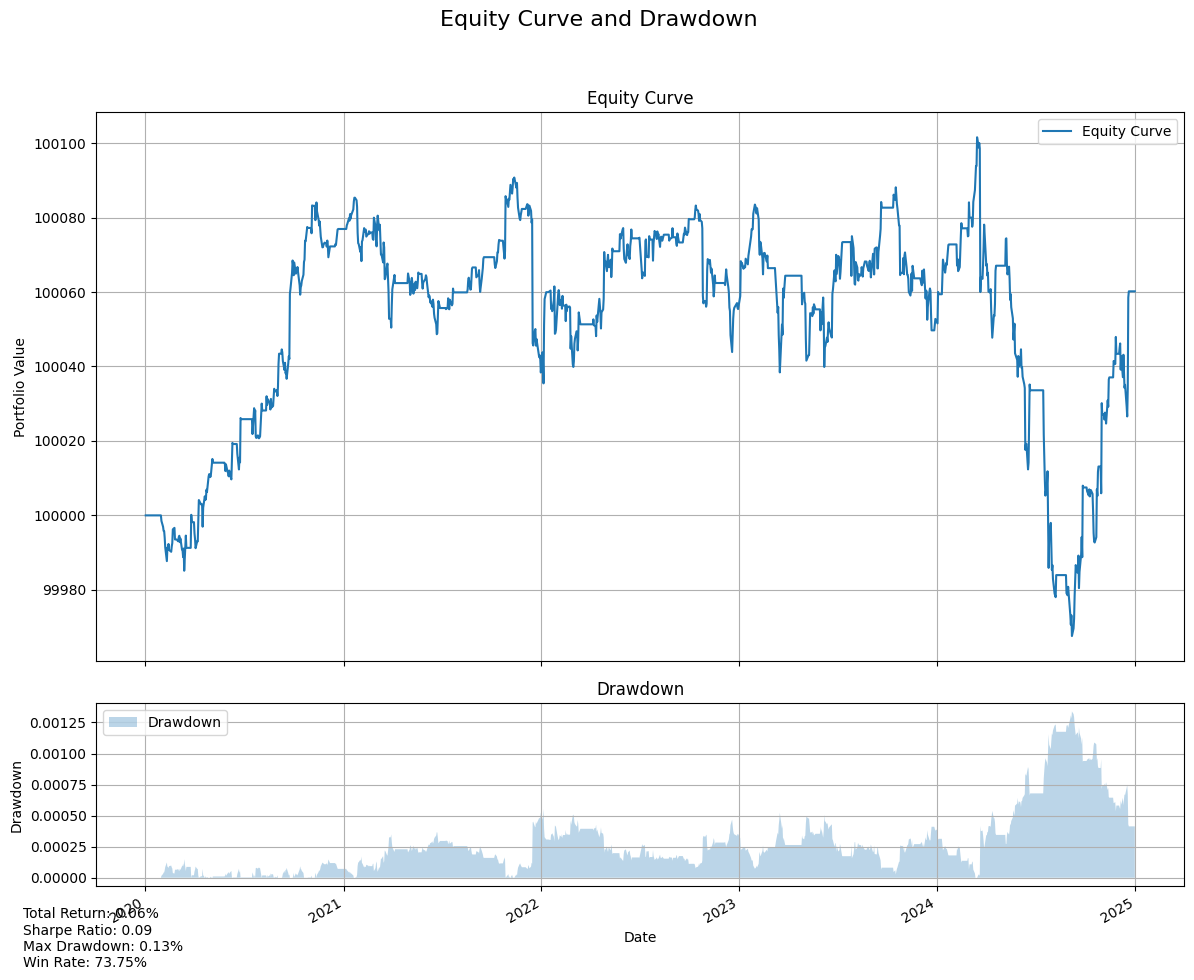

<IPython.core.display.Javascript object>

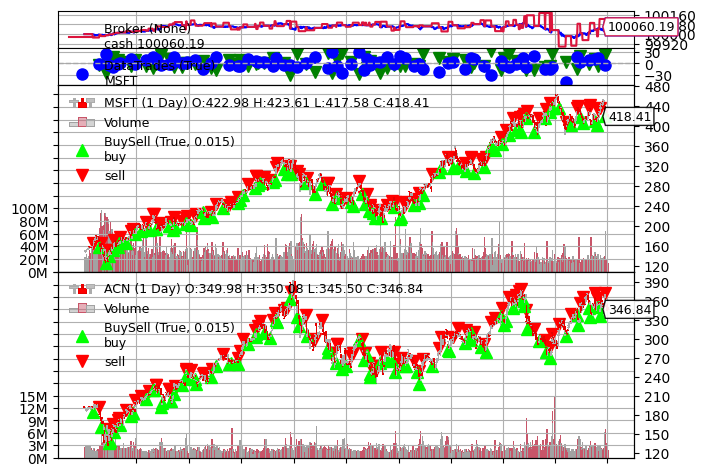

In [26]:
def main():
    # -------------------------
    # 1. Define all parameters
    # -------------------------
    params = {
        # Data parameters
        'stock1': "MSFT",
        'stock2': "ACN",
        'start_date': '2020-01-01',
        'end_date': '2025-01-01',
        
        # Strategy parameters
        'lookback': 20,
        'entry_threshold': 1.5,
        'stoploss_factor': 2.0,
        'kappa': 0.06,
        'half_life': 12.25,
        
        # Backtest parameters
        'initial_capital': 100000,
        'commission': 0.001,  # 0.1% commission
    }
    
    # -------------------------
    # 2. Load and align data
    # -------------------------
    df1 = pd.read_csv(f'stock_data/{params["stock1"]}.csv',
                      index_col='Date', parse_dates=True)
    df2 = pd.read_csv(f'stock_data/{params["stock2"]}.csv',
                      index_col='Date', parse_dates=True)

    # 如果 CSV 有多餘 header，可改用你註解的版本加 skiprows
    # df1 = pd.read_csv(f'stock_data/{params["stock1"]}.csv',
    #                   skiprows=2, index_col='Date', parse_dates=True)
    # df2 = pd.read_csv(f'stock_data/{params["stock2"]}.csv',
    #                   skiprows=2, index_col='Date', parse_dates=True)
    
    # 對齊日期區間
    common_dates = df1.index.intersection(df2.index)
    df1 = df1.loc[common_dates]
    df2 = df2.loc[common_dates]
    
    # ----------------------------------------------------
    # 3. Optionally calculate kappa & half-life on the fly
    # ----------------------------------------------------
    # 目前你已經手動填好值，如果要自動計算就把 params['kappa'] / ['half_life'] 設成 None
    if params['kappa'] is None or params['half_life'] is None:
        # 這裡假設你有一個 calculate_kappa_and_half_life(df1, df2) 的版本
        params['kappa'], params['half_life'] = calculate_kappa_and_half_life(df1, df2)
        print(f"Calculated Kappa: {params['kappa']:.4f}")
        print(f"Calculated Half-Life: {params['half_life']:.2f}")
    
    # -------------------------------
    # 4. 建立 BacktestEngine instance
    # -------------------------------
    # 這裡用 ticker 名稱當作 Backtrader data 的 name
    engine = BacktestEngine(
        strategy_class=PairTradingStrategy,
        df1=df1,
        df2=df2,
        ticker1=params['stock1'],        # "MSFT"
        ticker2=params['stock2'],        # "ACN"
        initial_capital=params['initial_capital'],
        commission=params['commission'],
    )

    # ------------------------------------
    # 5. 設定策略參數並加入到 Cerebro
    # ------------------------------------
    # 注意：不用再手動指定 stock1 / stock2，
    # BacktestEngine.set_strategy 會自動傳入 ticker1 / ticker2
    engine.set_strategy(
        lookback=params['lookback'],
        entry_threshold=params['entry_threshold'],
        stoploss_factor=params['stoploss_factor'],
        half_life=params['half_life'],
        # 你有需要的話可以把 kappa 也加到策略 params 裡
        # kappa=params['kappa'],
    )

    # -------------------------
    # 6. Run the backtest
    # -------------------------
    # engine.run() 內部會呼叫 add_data() 和 set_broker()
    engine.run()

    # -------------------------
    # 7. 輸出結果與圖表
    # -------------------------
    engine.print_metrics()        # 印出各種績效指標
    # engine.print_trade_table()  # 如果想看交易明細就打開這行

    engine.plot_equity_curve()    # 資產曲線 + DD
    engine.plot_results()         # Backtrader 自帶的 K 線 / 指標圖等

if __name__ == "__main__":
    main()

# 4. Bayesian optimization to find best parameters

### Define Bayesian Optimization Function

In [27]:
# from skopt import gp_minimize
# from skopt.space import Real, Integer
# from skopt.utils import use_named_args

# def objective(params, df1, df2, initial_capital=100000, commission=0.001):
#     lookback, entry_threshold, stoploss_factor, holding_time_factor, half_life = params
    
#     engine = BacktestEngine(
#         strategy_class=PairTradingStrategy,
#         df1=df1,
#         df2=df2,
#         initial_capital=initial_capital
#     )
    
#     engine.set_strategy(
#         lookback=int(lookback),
#         entry_threshold=entry_threshold,
#         stoploss_factor=stoploss_factor,
#         holding_time_factor=holding_time_factor,
#         half_life=half_life,
#         stock1="stock1",
#         stock2="stock2"
#     )
    
#     engine.set_broker(commission=commission, initial_capital=initial_capital)
#     engine.run()
#     metrics = engine.get_metrics()
    
#     # We want to maximize Sharpe Ratio, so we return its negative
#     return -metrics.get('Sharpe Ratio', 0)

# def bayesian_optimization(df1, df2, param_ranges, n_calls=50, initial_capital=100000, commission=0.001):
#     space = [
#         Integer(param_ranges['lookback'][0].min(), param_ranges['lookback'][0].max(), name='lookback'),
#         Real(param_ranges['entry_threshold'][0].min(), param_ranges['entry_threshold'][0].max(), name='entry_threshold'),
#         Real(param_ranges['stoploss_factor'][0].min(), param_ranges['stoploss_factor'][0].max(), name='stoploss_factor'),
#         Real(param_ranges['holding_time_factor'][0].min(), param_ranges['holding_time_factor'][0].max(), name='holding_time_factor'),
#     ]
    
#     fixed_half_life = param_ranges['half_life'][0]
    
#     @use_named_args(space)
#     def objective_wrapper(**params):
#         params_list = list(params.values()) + [fixed_half_life]
#         return objective(params_list, df1, df2, initial_capital, commission)
    
#     def callback(res):
#         n = len(res.x_iters)
#         print(f"Optimization progress: {n / n_calls * 100:.2f}%")
    
#     result = gp_minimize(objective_wrapper, space, n_calls=n_calls, random_state=42, callback=callback)
    
#     best_params = {
#         'lookback': int(result.x[0]),
#         'entry_threshold': result.x[1],
#         'stoploss_factor': result.x[2],
#         'holding_time_factor': result.x[3],
#         'half_life': fixed_half_life
#     }
    
#     return best_params, -result.fun  # Return best parameters and best Sharpe Ratio

In [28]:
def objective(params, df1, df2, initial_capital=100000, commission=0.001):
    """
    params: [lookback, entry_threshold, stoploss_factor, holding_time_factor, half_life]
    """
    lookback, entry_threshold, stoploss_factor, holding_time_factor, half_life = params
    
    # Create engine; commission is passed here so set_broker inside run() uses it
    engine = BacktestEngine(
        strategy_class=PairTradingStrategy,
        df1=df1,
        df2=df2,
        initial_capital=initial_capital,
        commission=commission,
    )
    
    # We let BacktestEngine.set_strategy inject stock1/stock2 names automatically
    engine.set_strategy(
        lookback=int(lookback),
        entry_threshold=entry_threshold,
        stoploss_factor=stoploss_factor,
        holding_time_factor=holding_time_factor,
        half_life=half_life,
    )
    
    # No need to call set_broker() separately; run() already does that
    engine.run()
    metrics = engine.get_metrics()
    
    # If something went wrong, penalize this parameter set with very bad Sharpe
    if isinstance(metrics, dict) and "Error" in metrics:
        return 1e6  # large positive (since we are minimizing)
    
    sharpe = metrics.get('Sharpe Ratio', 0.0)
    
    # We want to maximize Sharpe, so return its negative
    return -sharpe


def bayesian_optimization(df1, df2, param_ranges, n_calls=50,
                          initial_capital=100000, commission=0.001):
    """
    param_ranges: dict of (min, max) tuples, e.g.
        param_ranges = {
            'lookback': (10, 60),
            'entry_threshold': (0.5, 3.0),
            'stoploss_factor': (1.0, 4.0),
            'holding_time_factor': (0.5, 3.0),
            'half_life': 12.25,   # fixed value (scalar)
        }
    """
    # Search space for the optimizable parameters
    space = [
        Integer(param_ranges['lookback'][0], param_ranges['lookback'][1], name='lookback'),
        Real(param_ranges['entry_threshold'][0], param_ranges['entry_threshold'][1], name='entry_threshold'),
        Real(param_ranges['stoploss_factor'][0], param_ranges['stoploss_factor'][1], name='stoploss_factor'),
        Real(param_ranges['holding_time_factor'][0], param_ranges['holding_time_factor'][1], name='holding_time_factor'),
    ]
    
    # Fixed half-life (you can also make it a Real in the space if you want to optimize it too)
    fixed_half_life = param_ranges['half_life']
    
    @use_named_args(space)
    def objective_wrapper(**params):
        # params is a dict like {'lookback': ..., 'entry_threshold': ..., ...}
        params_list = [
            params['lookback'],
            params['entry_threshold'],
            params['stoploss_factor'],
            params['holding_time_factor'],
            fixed_half_life,
        ]
        return objective(params_list, df1, df2, initial_capital, commission)
    
    def callback(res):
        # res.x_iters contains all tried points so far
        n = len(res.x_iters)
        print(f"Optimization progress: {n / n_calls * 100:.2f}%")
    
    result = gp_minimize(
        objective_wrapper,
        space,
        n_calls=n_calls,
        random_state=42,
        callback=callback,
    )
    
    best_params = {
        'lookback': int(result.x[0]),
        'entry_threshold': result.x[1],
        'stoploss_factor': result.x[2],
        'holding_time_factor': result.x[3],
        'half_life': fixed_half_life,
    }
    
    best_sharpe = -result.fun  # because objective returns -Sharpe
    
    return best_params, best_sharpe

### Run to find best parameters

In [29]:
# import yfinance as yf
# import numpy as np
# %matplotlib inline

# def main():
#     # Find the best pair for pair trading
#     print("*" * 50)
#     print("Finding the best pair for pair trading...")
#     best_pair, suitable_pairs = find_best_pair(list_tickers)
#     print("Completed pair analysis.")
#     print("*" * 50)
#     if best_pair is None:
#         print("No suitable pairs found for pair trading.")
#         return
    
#     # get the best pair
#     stock1 = best_pair['stock1']
#     stock2 = best_pair['stock2']

#     # Download stock data
#     start_date = "2020-01-01"
#     end_date = "2023-01-01"
    
#     # df1 = yf.download(stock1, start=start_date, end=end_date, multi_level_index=False)
#     # df2 = yf.download(stock2, start=start_date, end=end_date, multi_level_index=False)
#     df1 = pd.read_csv(f'stock_data/{stock1}.csv', index_col='Date', parse_dates=True)
#     df2 = pd.read_csv(f'stock_data/{stock2}.csv', index_col='Date', parse_dates=True)

#     # Calculate kappa and half life
#     kappa, half_life = calculate_kappa_and_half_life(df1, df2, plot=False)
    
#     # Print CONFIG before optimization
#     print("*" * 50)
#     print("Stock Pair for Pair Trading:")
#     print(f'Stock 1: {stock1}')
#     print(f'Stock 2: {stock2}')
#     print(f'Kappa: {kappa:.2f}')
#     print(f'Half-Life: {half_life:.2f}')
#     print("*" * 50)
    
#     # Define parameter ranges for Bayesian optimization
#     look_back_range = np.arange(5, 31, 1)
#     entry_threshold_range = np.arange(1.5, 3.1, 0.1)
#     stoploss_factor_range = np.arange(1.5, 3.1, 0.1)
#     holding_time_factor_range = np.arange(1.0, 2.1, 0.1)
#     param_ranges = {
#         'lookback': [look_back_range],
#         'entry_threshold': [entry_threshold_range],
#         'stoploss_factor': [stoploss_factor_range],
#         'holding_time_factor': [holding_time_factor_range],
#         'half_life': [half_life]
#     }
    
#     # Run Bayesian optimization
#     best_params, best_sharpe = bayesian_optimization(df1, df2, param_ranges, n_calls=50)
    
#     print("*" * 50)
#     print("\nBest parameters found:")
#     for key, value in best_params.items():
#         print(f"{key}: {value}")
#     print(f"Best Sharpe Ratio: {best_sharpe}")
#     print("*" * 50)
    
#     # Run final backtest with best parameters
#     final_engine = BacktestEngine(
#         strategy_class=PairTradingStrategy,
#         df1=df1,
#         df2=df2,
#         initial_capital=100000
#     )
    
#     final_engine.set_strategy(**best_params, stock1="stock1", stock2="stock2")
    
#     final_engine.set_broker(commission=0.001, initial_capital=100000)
#     final_engine.run()
    
#     print("*" * 50)
#     print("\nFinal Backtest Results:")
#     final_engine.print_metrics()
#     final_engine.plot_equity_curve()

# if __name__ == "__main__":
#     main()

In [30]:
def make_ohlcv_from_close(close_series: pd.Series) -> pd.DataFrame:
    """
    Build a minimal OHLCV DataFrame from a close-price Series for Backtrader.
    We just set O/H/L = close, and volume = 1.
    """
    df = pd.DataFrame(index=close_series.index)
    df['open'] = close_series
    df['high'] = close_series
    df['low'] = close_series
    df['close'] = close_series
    df['volume'] = 1.0
    return df

# 1) Find the best pair for pair trading
print("*" * 50)
print("Finding the best pair for pair trading...")
best_pair, suitable_pairs = find_best_pair(available_stocks, close_df.loc['2016-01-01':'2020-12-31', :])
print("Completed pair analysis.")
print("*" * 50)

if best_pair is None:
    print("No suitable pairs found for pair trading.")

# Best pair tickers
stock1 = best_pair['stock1']
stock2 = best_pair['stock2']

# 2) Select date range and slice from close_df
start_date = "2021-01-01"
end_date = "2025-12-31"

pair_close = close_df[[stock1, stock2]].loc[start_date:end_date].dropna()
if pair_close.empty:
    print("No overlapping data for the selected date range.")

close1 = pair_close[stock1]
close2 = pair_close[stock2]

# 3) Build Backtrader OHLCV DataFrames from close prices
df1 = make_ohlcv_from_close(close1)
df2 = make_ohlcv_from_close(close2)

# 4) Calculate kappa and half-life from close_df
# (using the wrapper we wrote earlier)
kappa, half_life = calculate_kappa_and_half_life_from_close_df(
    stock1, stock2, close_df, plot=False
)

# Print config
print("*" * 50)
print("Stock Pair for Pair Trading:")
print(f"Stock 1: {stock1}")
print(f"Stock 2: {stock2}")
print(f"Kappa: {kappa:.4f}")
print(f"Half-Life: {half_life:.2f}")
print("*" * 50)

# 5) Define parameter ranges for Bayesian optimization
# We now use (min, max) tuples as required by the updated bayesian_optimization
param_ranges = {
    'lookback': (5, 30),              # Integer
    'entry_threshold': (1.5, 3.0),    # Real
    'stoploss_factor': (1.5, 3.0),    # Real
    'holding_time_factor': (1.0, 2.0),# Real
    'half_life': half_life            # fixed scalar
}

# 6) Run Bayesian optimization
best_params, best_sharpe = bayesian_optimization(
    df1=df1,
    df2=df2,
    param_ranges=param_ranges,
    n_calls=50,
    initial_capital=100000,
    commission=0.001,
)

print("*" * 50)
print("\nBest parameters found:")
for key, value in best_params.items():
    print(f"{key}: {value}")
print(f"Best Sharpe Ratio: {best_sharpe:.4f}")
print("*" * 50)

# 7) Run final backtest with best parameters
final_engine = BacktestEngine(
    strategy_class=PairTradingStrategy,
    df1=df1,
    df2=df2,
    ticker1=stock1,        # use real ticker names as Backtrader data names
    ticker2=stock2,
    initial_capital=100000,
    commission=0.001,
)

# BacktestEngine.set_strategy() will auto-inject stock1/stock2,
# so we just pass best_params
final_engine.set_strategy(**best_params)

final_engine.run()

print("*" * 50)
print("\nFinal Backtest Results:")
final_engine.print_metrics()
final_engine.plot_equity_curve()

**************************************************
Finding the best pair for pair trading...


100%|██████████| 165025/165025 [2:37:30<00:00, 17.46it/s]   


Completed pair analysis.
**************************************************
**************************************************
Stock Pair for Pair Trading:
Stock 1: NWS.OQ
Stock 2: NWSA.OQ
Kappa: 0.0046
Half-Life: 151.75
**************************************************
Optimization progress: 2.00%
Optimization progress: 4.00%
Optimization progress: 6.00%
Optimization progress: 8.00%
Optimization progress: 10.00%
Optimization progress: 12.00%
Optimization progress: 14.00%
Optimization progress: 16.00%
Optimization progress: 18.00%
Optimization progress: 20.00%
Optimization progress: 22.00%
Optimization progress: 24.00%
Optimization progress: 26.00%
Optimization progress: 28.00%
Optimization progress: 30.00%
Optimization progress: 32.00%
Optimization progress: 34.00%
Optimization progress: 36.00%
Optimization progress: 38.00%
Optimization progress: 40.00%
Optimization progress: 42.00%
Optimization progress: 44.00%
Optimization progress: 46.00%
Optimization progress: 48.00%
Optimization

<IPython.core.display.Javascript object>


Backtest Results:
+-----------------------------+-----------+
| Metric                      |     Value |
+=============================+===========+
| Initial Capital             | 100000    |
+-----------------------------+-----------+
| Final Portfolio Value       |  99996.6  |
+-----------------------------+-----------+
| Total Return (%)            |     -0    |
+-----------------------------+-----------+
| Sharpe Ratio                |      0.4  |
+-----------------------------+-----------+
| Max Drawdown (%)            |      0.01 |
+-----------------------------+-----------+
| Total Trades                |     39    |
+-----------------------------+-----------+
| Winning Trades              |     22    |
+-----------------------------+-----------+
| Losing Trades               |     17    |
+-----------------------------+-----------+
| Win Rate (%)                |     56.41 |
+-----------------------------+-----------+
| Mean Daily Return (%)       |      0    |
+------------

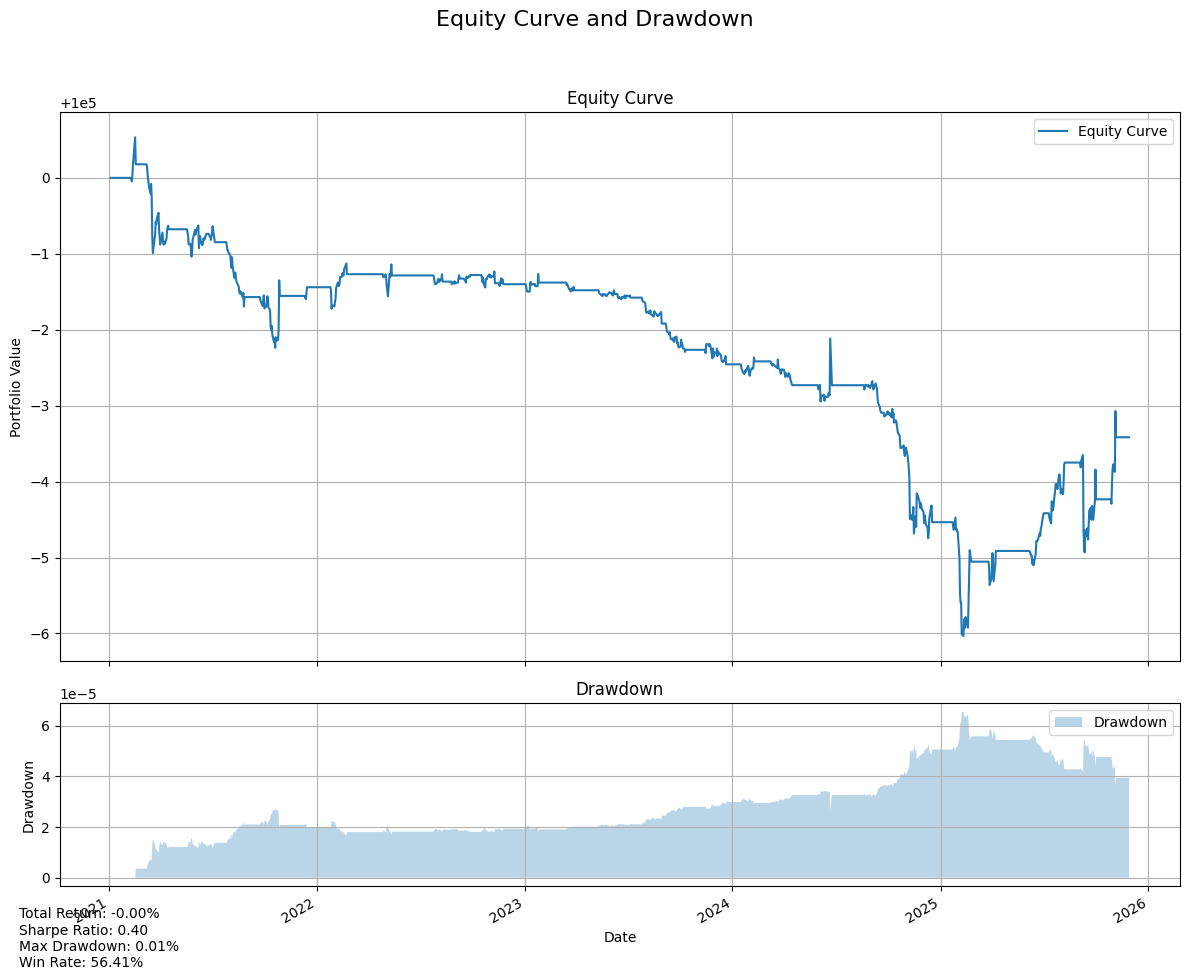

In [31]:
%matplotlib inline
final_engine.print_metrics()
final_engine.plot_equity_curve()

In [34]:
best_pair

{'stock1': 'NWS.OQ',
 'stock2': 'NWSA.OQ',
 'correlation': 0.9954289643670807,
 'cointegration_pvalue': 0.035576946625267274,
 'adf_pvalue': 0.011306606555563184,
 'mean_zscore': 4.514965755425577e-17,
 'std_zscore': 1.0,
 'log_spread': Date
 2016-01-04     0.03423
 2016-01-05    0.026277
 2016-01-06    0.040098
 2016-01-07     0.04641
 2016-01-08     0.03361
                 ...   
 2020-12-24   -0.007887
 2020-12-28   -0.005239
 2020-12-29   -0.009479
 2020-12-30   -0.006678
 2020-12-31   -0.011192
 Length: 1259, dtype: Float64,
 'z_score': Date
 2016-01-04    0.937297
 2016-01-05    0.340992
 2016-01-06    1.377304
 2016-01-07    1.850599
 2016-01-08    0.890848
                 ...   
 2020-12-24   -2.220606
 2020-12-28    -2.02205
 2020-12-29   -2.339927
 2020-12-30   -2.129915
 2020-12-31   -2.468391
 Length: 1259, dtype: Float64}

In [37]:
suitable_pairs

,pair,cointegration_pvalue,correlation,adf_pvalue,mean_zscore,std_zscore
147447,NWS.OQ-NWSA.OQ,0.035577,0.995429,0.011307,4.514966e-17,1.0
100270,FRT.N-REG.OQ,0.002091,0.989803,0.015138,-1.128741e-16,1.0
146255,NSC.N-UNP.N,0.002283,0.989067,0.035889,0.000000e+00,1.0
4866,ACN.N-LIN.OQ,0.000006,0.987820,0.000002,-3.386224e-17,1.0
132303,LRCX.OQ-TER.OQ,0.001756,0.987749,0.001280,2.483231e-16,1.0
...,...,...,...,...,...,...
85699,ENDP.OQ^H22-HPQ.N,0.011306,-0.570732,0.043874,-1.354490e-16,1.0
16041,ALXN.OQ^G21-NOC.N,0.000039,-0.593054,0.037139,0.000000e+00,1.0
79135,DTE.N-ENDP.OQ^H22,0.048906,-0.651960,0.048001,2.708979e-16,1.0
85791,ENDP.OQ^H22-MLM.N,0.027107,-0.669440,0.043951,-4.514966e-17,1.0


In [36]:
suitable_pairs.to_csv('suitable_pairs.csv')

In [33]:
final_engine.print_trade_table()


Trade History:
+--------------+-------------+-------------+-------+---------+-----------------+-----------------+----------------+----------------+-------------+------------------+
| Entry Date   | Exit Date   |   Days Held |   PnL | PnL %   |   Entry Price 1 |   Entry Price 2 |   Exit Price 1 |   Exit Price 2 | Exit Type   | Exit Reason      |
+==============+=============+=============+=======+=========+=================+=================+================+================+=============+==================+
| 2021-02-09   | 2021-02-16  |           4 |  0.53 | 0.00%   |           21.97 |           22.18 |          23.2  |          23.79 | EXIT        | Spread Reversion |
+--------------+-------------+-------------+-------+---------+-----------------+-----------------+----------------+----------------+-------------+------------------+
| 2021-03-08   | 2021-04-15  |          27 | -0.81 | -0.00%  |           23.23 |           24.24 |          24.8  |          26.61 | EXIT        | Spread 